# Taller 07 — Sistema RAG Académico
## Universidad Nacional de Colombia · IA y Minirobots 2026-I

**Objetivo:** Construir un sistema de Recuperación Aumentada por Generación (RAG) que permita
consultar información actualizada de la Universidad Nacional de Colombia u otra entidad,
combinando búsqueda semántica densa con generación de lenguaje natural.

### Arquitectura del sistema

```
┌─────────────────────────────────────────────────────────────────┐
│                        PIPELINE RAG                             │
│                                                                 │
│  [Documentos / Web]                                             │
│        │                                                        │
│        ▼                                                        │
│  [Carga & Limpieza]  ──►  [Chunking Semántico]                  │
│                                   │                            │
│                                   ▼                            │
│                          [Embeddings (SBERT)]                   │
│                                   │                            │
│                                   ▼                            │
│                          [FAISS Vector Store]                   │
│                                   │                            │
│  [Pregunta usuario]               │                            │
│        │                          │                            │
│        ▼                          │                            │
│  [Query Embedding] ──► [Retrieval Top-K + Reranking]            │
│                                   │                            │
│                                   ▼                            │
│                          [Prompt Engineering]                   │
│                                   │                            │
│                                   ▼                            │
│                          [LLM (OpenAI / Ollama)]                │
│                                   │                            │
│                                   ▼                            │
│                          [Respuesta + Fuentes]                  │
└─────────────────────────────────────────────────────────────────┘
```

### Componentes principales
| Módulo | Tecnología |
|---|---|
| Embeddings | `sentence-transformers` (paraphrase-multilingual-MiniLM-L12-v2) |
| Vector Store | `FAISS` (Facebook AI Similarity Search) |
| Reranking | Cross-encoder `ms-marco-MiniLM-L-6-v2` |
| LLM | Ollama (local) / OpenAI GPT-4o-mini |
| Web Scraping | `requests` + `BeautifulSoup4` |
| PDF | `PyMuPDF` (fitz) |


## Celda 0 — Instalación de dependencias

In [1]:
# Ejecutar una sola vez
%pip install -q \
    sentence-transformers \
    faiss-cpu \
    openai \
    requests \
    beautifulsoup4 \
    pymupdf \
    tiktoken \
    numpy \
    matplotlib \
    tqdm \
    python-dotenv

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


## Celda 1 — Imports y configuración global

In [2]:
import os, re, json, time, textwrap, warnings
from pathlib import Path
from dataclasses import dataclass, field
from typing import List, Dict, Optional, Tuple

import numpy as np
import requests
from bs4 import BeautifulSoup
import fitz  # PyMuPDF
import faiss
from sentence_transformers import SentenceTransformer, CrossEncoder
from tqdm.auto import tqdm
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from dotenv import load_dotenv

warnings.filterwarnings('ignore')
load_dotenv()  # carga OPENAI_API_KEY desde .env si existe

# ── Configuración global ──────────────────────────────────────────
CFG = {
    # Modelos
    'embed_model'  : 'paraphrase-multilingual-MiniLM-L12-v2',  # multilingüe ES/EN
    'rerank_model' : 'cross-encoder/ms-marco-MiniLM-L-6-v2',
    'llm_provider' : 'ollama',   # 'openai' | 'ollama'
    'llm_model'    : 'gpt-4o-mini',
    'ollama_url'   : 'http://localhost:11434/api/generate',
    'ollama_model' : 'llama3.2',
    # Chunking
    'chunk_size'   : 400,   # tokens aprox.
    'chunk_overlap': 80,
    # Retrieval
    'top_k_retrieve': 10,
    'top_k_rerank'  : 4,
    # Paths
    'index_path'   : 'rag_index.faiss',
    'meta_path'    : 'rag_meta.json',
}

OPENAI_KEY = os.getenv('OPENAI_API_KEY', '')
print('✓ Configuración cargada')
print(f"  LLM provider : {CFG['llm_provider']}")
print(f"  Embed model  : {CFG['embed_model']}")
print(f"  OpenAI key   : {'configurada' if OPENAI_KEY else 'NO configurada (se usará Ollama o modo demo)'}")

C:\Users\Juan Tinjaca\AppData\Roaming\Python\Python314\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


✓ Configuración cargada
  LLM provider : ollama
  Embed model  : paraphrase-multilingual-MiniLM-L12-v2
  OpenAI key   : NO configurada (se usará Ollama o modo demo)


## Celda 2 — Modelo de datos: Documento y Chunk

In [3]:
@dataclass
class Document:
    """Unidad de ingesta: un documento completo con metadatos."""
    content : str
    source  : str                    # URL o ruta de archivo
    title   : str = ''
    metadata: Dict = field(default_factory=dict)


@dataclass
class Chunk:
    """Fragmento indexable con su embedding y trazabilidad al documento origen."""
    text    : str
    source  : str
    title   : str
    chunk_id: int
    metadata: Dict = field(default_factory=dict)

    def to_dict(self) -> Dict:
        return {
            'text'    : self.text,
            'source'  : self.source,
            'title'   : self.title,
            'chunk_id': self.chunk_id,
            'metadata': self.metadata,
        }

    @staticmethod
    def from_dict(d: Dict) -> 'Chunk':
        return Chunk(**d)

print('✓ Modelos de datos definidos')

✓ Modelos de datos definidos


## Celda 3 — Cargadores de documentos (PDF y Web)

In [4]:
class PDFLoader:
    """Carga documentos PDF usando PyMuPDF."""

    @staticmethod
    def load(path: str) -> Document:
        doc = fitz.open(path)
        pages = [page.get_text() for page in doc]
        content = '\n'.join(pages)
        title = Path(path).stem.replace('_', ' ').title()
        return Document(content=content, source=path, title=title,
                        metadata={'pages': len(pages), 'type': 'pdf'})


class WebLoader:
    """Carga y limpia contenido HTML de una URL."""

    HEADERS = {'User-Agent': 'Mozilla/5.0 (RAG-Academic-Bot/1.0)'}

    @classmethod
    def load(cls, url: str, timeout: int = 15) -> Optional[Document]:
        try:
            resp = requests.get(url, headers=cls.HEADERS, timeout=timeout, verify=False)
            resp.raise_for_status()
            soup = BeautifulSoup(resp.text, 'html.parser')

            # Eliminar scripts, estilos y navegación
            for tag in soup(['script', 'style', 'nav', 'footer', 'header', 'aside']):
                tag.decompose()

            title = soup.title.string.strip() if soup.title else url
            # Extraer texto de párrafos, encabezados y listas
            blocks = soup.find_all(['p', 'h1', 'h2', 'h3', 'h4', 'li', 'td', 'th'])
            content = '\n'.join(b.get_text(separator=' ', strip=True) for b in blocks)
            content = re.sub(r'\n{3,}', '\n\n', content)  # colapsar líneas vacías

            return Document(content=content, source=url, title=title,
                            metadata={'type': 'web', 'status': resp.status_code})
        except Exception as e:
            print(f'  ⚠ Error cargando {url}: {e}')
            return None


class TextLoader:
    """Carga texto plano o markdown."""

    @staticmethod
    def load(path: str) -> Document:
        text = Path(path).read_text(encoding='utf-8', errors='ignore')
        title = Path(path).stem.replace('_', ' ').title()
        return Document(content=text, source=path, title=title,
                        metadata={'type': 'text'})

print('✓ Cargadores definidos: PDFLoader, WebLoader, TextLoader')

✓ Cargadores definidos: PDFLoader, WebLoader, TextLoader


## Celda 4 — Chunking semántico con solapamiento

In [5]:
class SemanticChunker:
    """
    Divide documentos en chunks con solapamiento controlado.
    Estrategia: split por oraciones → agrupa hasta chunk_size palabras
    con overlap de chunk_overlap palabras entre chunks consecutivos.
    """

    def __init__(self, chunk_size: int = 400, chunk_overlap: int = 80):
        self.chunk_size    = chunk_size
        self.chunk_overlap = chunk_overlap

    def _split_sentences(self, text: str) -> List[str]:
        """Divide en oraciones usando puntuación."""
        sentences = re.split(r'(?<=[.!?\n])\s+', text.strip())
        return [s.strip() for s in sentences if len(s.strip()) > 10]

    def _word_count(self, text: str) -> int:
        return len(text.split())

    def chunk(self, doc: Document) -> List[Chunk]:
        sentences = self._split_sentences(doc.content)
        chunks: List[Chunk] = []
        buffer: List[str] = []
        buf_words = 0
        chunk_id = 0

        for sent in sentences:
            sw = self._word_count(sent)
            if buf_words + sw > self.chunk_size and buffer:
                # Guardar chunk actual
                text = ' '.join(buffer)
                chunks.append(Chunk(
                    text=text, source=doc.source, title=doc.title,
                    chunk_id=chunk_id, metadata={**doc.metadata, 'chunk_index': chunk_id}
                ))
                chunk_id += 1
                # Overlap: conservar últimas palabras
                overlap_text = ' '.join(buffer)
                overlap_words = overlap_text.split()[-self.chunk_overlap:]
                buffer = [' '.join(overlap_words)]
                buf_words = len(overlap_words)
            buffer.append(sent)
            buf_words += sw

        if buffer:  # último chunk
            chunks.append(Chunk(
                text=' '.join(buffer), source=doc.source, title=doc.title,
                chunk_id=chunk_id, metadata={**doc.metadata, 'chunk_index': chunk_id}
            ))
        return chunks


# ── Demo rápida ───────────────────────────────────────────────────
demo_doc = Document(
    content="""La Universidad Nacional de Colombia es la universidad pública más importante del país.
    Fue fundada en 1867 y tiene sedes en varias ciudades colombianas.
    La sede Bogotá es la principal y alberga la Facultad de Ingeniería.
    El programa de Ingeniería Mecatrónica integra mecánica, electrónica y sistemas.
    Los estudiantes aprenden inteligencia artificial, robótica y automatización.""",
    source='demo', title='Demo UNAL'
)
chunker = SemanticChunker(chunk_size=30, chunk_overlap=5)
demo_chunks = chunker.chunk(demo_doc)
print(f'✓ Chunker listo — Demo: {len(demo_chunks)} chunks generados')
for i, c in enumerate(demo_chunks):
    print(f'  Chunk {i}: {len(c.text.split())} palabras — "{c.text[:60]}..."')

✓ Chunker listo — Demo: 3 chunks generados
  Chunk 0: 24 palabras — "La Universidad Nacional de Colombia es la universidad públic..."
  Chunk 1: 27 palabras — "sedes en varias ciudades colombianas. La sede Bogotá es la p..."
  Chunk 2: 13 palabras — "integra mecánica, electrónica y sistemas. Los estudiantes ap..."


## Celda 5 — Vector Store con FAISS

In [6]:
class FAISSVectorStore:
    """
    Almacén vectorial basado en FAISS con índice IVF para búsqueda eficiente.
    Soporta persistencia en disco y búsqueda por similitud coseno.
    """

    def __init__(self, embed_dim: int):
        self.embed_dim = embed_dim
        self.chunks: List[Chunk] = []
        # IndexFlatIP = producto interno (equivale a coseno si vectores normalizados)
        self.index = faiss.IndexFlatIP(embed_dim)

    def add(self, chunks: List[Chunk], embeddings: np.ndarray):
        """Agrega chunks y sus embeddings al índice."""
        assert len(chunks) == len(embeddings)
        # Normalizar para similitud coseno
        norms = np.linalg.norm(embeddings, axis=1, keepdims=True)
        embeddings_norm = embeddings / (norms + 1e-10)
        self.index.add(embeddings_norm.astype('float32'))
        self.chunks.extend(chunks)

    def search(self, query_emb: np.ndarray, top_k: int = 10) -> List[Tuple[Chunk, float]]:
        """Retorna los top_k chunks más similares con su score."""
        q = query_emb / (np.linalg.norm(query_emb) + 1e-10)
        q = q.reshape(1, -1).astype('float32')
        scores, indices = self.index.search(q, min(top_k, len(self.chunks)))
        results = []
        for score, idx in zip(scores[0], indices[0]):
            if idx >= 0:
                results.append((self.chunks[idx], float(score)))
        return results

    def save(self, index_path: str, meta_path: str):
        faiss.write_index(self.index, index_path)
        with open(meta_path, 'w', encoding='utf-8') as f:
            json.dump([c.to_dict() for c in self.chunks], f, ensure_ascii=False, indent=2)
        print(f'✓ Índice guardado: {index_path} ({len(self.chunks)} chunks)')

    @classmethod
    def load(cls, index_path: str, meta_path: str, embed_dim: int) -> 'FAISSVectorStore':
        store = cls(embed_dim)
        store.index = faiss.read_index(index_path)
        with open(meta_path, 'r', encoding='utf-8') as f:
            store.chunks = [Chunk.from_dict(d) for d in json.load(f)]
        print(f'✓ Índice cargado: {len(store.chunks)} chunks')
        return store

    def __len__(self):
        return len(self.chunks)

print('✓ FAISSVectorStore definido')

✓ FAISSVectorStore definido


## Celda 6 — Motor de embeddings y reranking

In [7]:
class EmbeddingEngine:
    """
    Genera embeddings densos usando sentence-transformers.
    Modelo multilingüe para soporte español/inglés.
    """

    def __init__(self, model_name: str):
        print(f'  Cargando modelo de embeddings: {model_name}...')
        self.model = SentenceTransformer(model_name)
        self.dim = self.model.get_sentence_embedding_dimension()
        print(f'  ✓ Dimensión de embedding: {self.dim}')

    def encode(self, texts: List[str], batch_size: int = 64,
               show_progress: bool = True) -> np.ndarray:
        return self.model.encode(
            texts, batch_size=batch_size,
            show_progress_bar=show_progress,
            normalize_embeddings=False,
            convert_to_numpy=True
        )


class Reranker:
    """
    Cross-encoder para reordenar candidatos recuperados.
    Más preciso que bi-encoder pero más lento → se aplica solo a top-K.
    """

    def __init__(self, model_name: str):
        print(f'  Cargando cross-encoder: {model_name}...')
        self.model = CrossEncoder(model_name)
        print('  ✓ Reranker listo')

    def rerank(self, query: str, candidates: List[Tuple[Chunk, float]],
               top_k: int = 4) -> List[Tuple[Chunk, float]]:
        if not candidates:
            return []
        pairs = [(query, c.text) for c, _ in candidates]
        scores = self.model.predict(pairs)
        ranked = sorted(zip(candidates, scores), key=lambda x: x[1], reverse=True)
        return [(chunk, float(score)) for (chunk, _), score in ranked[:top_k]]


# ── Inicializar modelos ───────────────────────────────────────────
print('Inicializando modelos (puede tardar la primera vez)...')
embedder = EmbeddingEngine(CFG['embed_model'])
reranker  = Reranker(CFG['rerank_model'])
print('\n✓ Modelos listos')

Inicializando modelos (puede tardar la primera vez)...
  Cargando modelo de embeddings: paraphrase-multilingual-MiniLM-L12-v2...


Loading weights: 100%|██████████| 199/199 [00:00<00:00, 7548.08it/s]
BertModel LOAD REPORT from: sentence-transformers/paraphrase-multilingual-MiniLM-L12-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


  ✓ Dimensión de embedding: 384
  Cargando cross-encoder: cross-encoder/ms-marco-MiniLM-L-6-v2...


Loading weights: 100%|██████████| 105/105 [00:00<00:00, 8294.91it/s]
BertForSequenceClassification LOAD REPORT from: cross-encoder/ms-marco-MiniLM-L-6-v2
Key                          | Status     |  | 
-----------------------------+------------+--+-
bert.embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


  ✓ Reranker listo

✓ Modelos listos


## Celda 7 — Generador LLM (OpenAI / Ollama)

In [8]:
class LLMGenerator:
    """
    Abstracción sobre proveedores LLM.
    Soporta OpenAI (API) y Ollama (local).
    """

    SYSTEM_PROMPT = """Eres un asistente académico especializado en información de la \
Universidad Nacional de Colombia. Responde en español de forma clara, precisa y académica. \
Basa tus respuestas ÚNICAMENTE en el contexto proporcionado. \
Si la información no está en el contexto, indícalo explícitamente. \
Cita las fuentes al final de tu respuesta."""

    def __init__(self, provider: str, model: str, api_key: str = '',
                 ollama_url: str = '', ollama_model: str = 'llama3'):
        self.provider    = provider
        self.model       = model
        self.api_key     = api_key
        self.ollama_url  = ollama_url
        self.ollama_model = ollama_model

    def _build_prompt(self, query: str, context_chunks: List[Tuple[Chunk, float]]) -> str:
        context_parts = []
        for i, (chunk, score) in enumerate(context_chunks, 1):
            context_parts.append(
                f"[Fuente {i}] {chunk.title}\n{chunk.text}\n(score: {score:.3f})"
            )
        context_str = '\n\n---\n\n'.join(context_parts)
        return f"""CONTEXTO RECUPERADO:
{context_str}

PREGUNTA: {query}

RESPUESTA (basada únicamente en el contexto anterior):"""

    def generate_openai(self, query: str, context_chunks: List[Tuple[Chunk, float]]) -> str:
        from openai import OpenAI
        client = OpenAI(api_key=self.api_key)
        prompt = self._build_prompt(query, context_chunks)
        response = client.chat.completions.create(
            model=self.model,
            messages=[
                {'role': 'system', 'content': self.SYSTEM_PROMPT},
                {'role': 'user',   'content': prompt}
            ],
            temperature=0.2,
            max_tokens=1024,
        )
        return response.choices[0].message.content

    def generate_ollama(self, query: str, context_chunks: List[Tuple[Chunk, float]]) -> str:
        prompt = self.SYSTEM_PROMPT + '\n\n' + self._build_prompt(query, context_chunks)
        payload = {'model': self.ollama_model, 'prompt': prompt, 'stream': False}
        resp = requests.post(self.ollama_url, json=payload, timeout=120)
        resp.raise_for_status()
        return resp.json().get('response', '')

    def generate_demo(self, query: str, context_chunks: List[Tuple[Chunk, float]]) -> str:
        """Modo demo sin LLM: muestra el contexto recuperado."""
        lines = [f'[MODO DEMO — sin LLM configurado]\n',
                 f'Pregunta: {query}\n',
                 f'Contexto recuperado ({len(context_chunks)} fragmentos):\n']
        for i, (chunk, score) in enumerate(context_chunks, 1):
            lines.append(f'  [{i}] (score={score:.3f}) {chunk.title}: {chunk.text[:150]}...')
        return '\n'.join(lines)

    def generate(self, query: str, context_chunks: List[Tuple[Chunk, float]]) -> str:
        if self.provider == 'openai' and self.api_key:
            return self.generate_openai(query, context_chunks)
        elif self.provider == 'ollama':
            return self.generate_ollama(query, context_chunks)
        else:
            return self.generate_demo(query, context_chunks)


llm = LLMGenerator(
    provider=CFG['llm_provider'], model=CFG['llm_model'],
    api_key=OPENAI_KEY, ollama_url=CFG['ollama_url'],
    ollama_model=CFG['ollama_model']
)
print(f'✓ LLMGenerator listo — modo: {CFG["llm_provider"]}')

✓ LLMGenerator listo — modo: ollama


## Celda 8 — Pipeline RAG completo

In [9]:
class RAGPipeline:
    """
    Pipeline RAG completo:
      Ingesta → Chunking → Embedding → FAISS → Retrieval → Reranking → LLM
    """

    def __init__(self, embedder: EmbeddingEngine, reranker: Reranker,
                 llm: LLMGenerator, chunker: SemanticChunker,
                 top_k_retrieve: int = 10, top_k_rerank: int = 4):
        self.embedder       = embedder
        self.reranker       = reranker
        self.llm            = llm
        self.chunker        = chunker
        self.top_k_retrieve = top_k_retrieve
        self.top_k_rerank   = top_k_rerank
        self.store          = FAISSVectorStore(embedder.dim)
        self.history: List[Dict] = []  # historial de conversación

    # ── Ingesta ──────────────────────────────────────────────────
    def ingest(self, documents: List[Document]):
        """Procesa documentos: chunking + embedding + indexación."""
        all_chunks: List[Chunk] = []
        for doc in documents:
            chunks = self.chunker.chunk(doc)
            all_chunks.extend(chunks)
            print(f'  {doc.title}: {len(chunks)} chunks')

        print(f'\nGenerando embeddings para {len(all_chunks)} chunks...')
        texts = [c.text for c in all_chunks]
        embeddings = self.embedder.encode(texts)
        self.store.add(all_chunks, embeddings)
        print(f'✓ Ingesta completa — {len(self.store)} chunks indexados')

    def save_index(self):
        self.store.save(CFG['index_path'], CFG['meta_path'])

    def load_index(self):
        self.store = FAISSVectorStore.load(
            CFG['index_path'], CFG['meta_path'], self.embedder.dim
        )

    # ── Consulta ─────────────────────────────────────────────────
    def query(self, question: str, verbose: bool = False) -> Dict:
        """Ejecuta el pipeline completo para una pregunta."""
        t0 = time.time()

        # 1. Embedding de la consulta
        q_emb = self.embedder.encode([question], show_progress=False)[0]

        # 2. Recuperación densa (FAISS)
        candidates = self.store.search(q_emb, top_k=self.top_k_retrieve)

        # 3. Reranking con cross-encoder
        reranked = self.reranker.rerank(question, candidates, top_k=self.top_k_rerank)

        # 4. Generación
        answer = self.llm.generate(question, reranked)

        elapsed = time.time() - t0
        result = {
            'question'  : question,
            'answer'    : answer,
            'sources'   : [{'title': c.title, 'source': c.source,
                            'score': round(s, 4), 'text': c.text[:200]}
                           for c, s in reranked],
            'elapsed_s' : round(elapsed, 2),
            'n_retrieved': len(candidates),
        }
        self.history.append(result)

        if verbose:
            print(f'\n{'='*60}')
            print(f'Pregunta: {question}')
            print(f'{'='*60}')
            print(f'\nRespuesta:\n{answer}')
            print(f'\nFuentes utilizadas:')
            for i, s in enumerate(result['sources'], 1):
                print(f'  [{i}] {s["title"]} (score={s["score"]}) — {s["source"]}')
            print(f'\nTiempo total: {elapsed:.2f}s')
        return result

    def chat(self, question: str) -> str:
        """Interfaz simplificada para chat interactivo."""
        result = self.query(question, verbose=True)
        return result['answer']


# ── Instanciar pipeline ───────────────────────────────────────────
chunker = SemanticChunker(CFG['chunk_size'], CFG['chunk_overlap'])
rag = RAGPipeline(
    embedder=embedder, reranker=reranker, llm=llm, chunker=chunker,
    top_k_retrieve=CFG['top_k_retrieve'], top_k_rerank=CFG['top_k_rerank']
)
print('✓ RAGPipeline instanciado')

✓ RAGPipeline instanciado


## Celda 9 — Ingesta de fuentes UNAL

Se cargan páginas web oficiales de la Universidad Nacional de Colombia.
Puedes agregar PDFs locales con `PDFLoader.load('ruta/archivo.pdf')`.

In [10]:
# ── URLs alternativas (Wikipedia + fuentes abiertas) ─────────────
# El sitio oficial de la UNAL bloquea scraping (403/SSL/timeout).
# Se usan fuentes abiertas con contenido académico equivalente.
UNAL_URLS = [
    'https://es.wikipedia.org/wiki/Universidad_Nacional_de_Colombia',
    'https://es.wikipedia.org/wiki/Facultad_de_Ingenier%C3%ADa_de_la_Universidad_Nacional_de_Colombia',
    'https://es.wikipedia.org/wiki/Inteligencia_artificial',
    'https://es.wikipedia.org/wiki/Aprendizaje_autom%C3%A1tico',
    'https://es.wikipedia.org/wiki/Red_neuronal_artificial',
    'https://es.wikipedia.org/wiki/Algoritmo_gen%C3%A9tico',
    'https://es.wikipedia.org/wiki/Generaci%C3%B3n_aumentada_por_recuperaci%C3%B3n',
]

# ── Texto base del curso (siempre disponible) ─────────────────────
COURSE_TEXT = """Universidad Nacional de Colombia - Sede Bogotá
Facultad de Ingeniería
Inteligencia Artificial y Minirobots - I semestre 2026
Código: 2023251 - Créditos: 3

ORIENTACIÓN: El curso está dirigido a estudiantes de ingenierías mecatrónica, mecánica,
eléctrica, electrónica, industrial y de sistemas interesados en técnicas básicas de
inteligencia artificial con aplicaciones a problemas de ingeniería.

CONTENIDO:
1. Panorama de la IA: enfoques, sistemas, complejidad computacional, herramientas.
2. Autómatas Celulares: vecindades, definición formal, AC 1D y 2D, Life, aplicaciones.
3. Algoritmos Genéticos: descripción, solución de problemas de alta complejidad.
4. Programación Genética: terminales, funciones, aptitud, operadores.
5. Redes Neuronales: neurona artificial, redes feed-forward, retro-propagación, deep learning.
6. Introducción a ML: tipos de aprendizaje supervisado, semi-supervisado, no supervisado, reforzado.
7. IA Generativa: LLMs, Transformers, Modelos Fundacionales.
8. Lógica Fuzzy: conjuntos difusos, operaciones, sistemas difusos.
9. Percepción Visual en Robótica: visión por computador, CNNs, detección de objetos.
10. Control Servovisual: control basado en posición vs imagen, estimación de pose.
11. Aprendizaje Profundo en Servovisualización: CNNs, RNNs/LSTMs para robótica.
12. Aprendizaje por Refuerzo: Deep RL, control autónomo con visión.
13. Aplicaciones en Minirobots: seguimiento visual, manipulación, navegación autónoma.

EVALUACIÓN: 40% Proyectos, 35% Talleres y tareas, 25% Examen.
Profesores: José Martínez P., Gustavo Pérez H., Flavio Prieto.

METODOLOGÍA: Clases magistrales (60%), talleres de programación (40%), lecturas extra-clase.
"""

documents: List[Document] = []

# Documento del curso (siempre disponible)
documents.append(Document(
    content=COURSE_TEXT,
    source='syllabus_ia_minirobots_2026',
    title='Syllabus IA y Minirobots 2026-I',
    metadata={'type': 'text', 'institution': 'UNAL'}
))

# Scraping de páginas web UNAL
print('Cargando páginas web de la UNAL...')
for url in tqdm(UNAL_URLS):
    doc = WebLoader.load(url)
    if doc and len(doc.content) > 200:
        documents.append(doc)
        print(f'  ✓ {doc.title[:60]} ({len(doc.content)} chars)')

# ── Agregar PDFs locales (opcional) ──────────────────────────────
# pdf_files = list(Path('.').glob('*.pdf'))
# for pdf in pdf_files:
#     documents.append(PDFLoader.load(str(pdf)))

print(f'\n✓ Total documentos cargados: {len(documents)}')

Cargando páginas web de la UNAL...


 14%|█▍        | 1/7 [00:00<00:04,  1.40it/s]

  ✓ Universidad Nacional de Colombia - Wikipedia, la enciclopedi (40260 chars)


 29%|██▊       | 2/7 [00:01<00:03,  1.58it/s]

  ⚠ Error cargando https://es.wikipedia.org/wiki/Facultad_de_Ingenier%C3%ADa_de_la_Universidad_Nacional_de_Colombia: 404 Client Error: Not Found for url: https://es.wikipedia.org/wiki/Facultad_de_Ingenier%C3%ADa_de_la_Universidad_Nacional_de_Colombia


...

  ✓ Red neuronal artificial - Wikipedia, la enciclopedia libre (72852 chars)


 86%|████████▌ | 6/7 [00:04<00:00,  1.45it/s]

  ✓ Algoritmo genético - Wikipedia, la enciclopedia libre (55312 chars)


100%|██████████| 7/7 [00:04<00:00,  1.44it/s]

  ✓ Generación aumentada por recuperación - Wikipedia, la encicl (21005 chars)

✓ Total documentos cargados: 7


## Celda 10 — Construcción del índice vectorial

In [11]:
index_exists = Path(CFG['index_path']).exists() and Path(CFG['meta_path']).exists()

if index_exists:
    print('Índice existente encontrado. Cargando...')
    rag.load_index()
else:
    print('Construyendo índice desde cero...')
    rag.ingest(documents)
    rag.save_index()

print(f'\n✓ Índice listo — {len(rag.store)} chunks disponibles para consulta')

Construyendo índice desde cero...
  Syllabus IA y Minirobots 2026-I: 1 chunks
  Universidad Nacional de Colombia - Wikipedia, la enciclopedia libre: 23 chunks
  Inteligencia artificial - Wikipedia, la enciclopedia libre: 54 chunks
  Aprendizaje automático - Wikipedia, la enciclopedia libre: 10 chunks
  Red neuronal artificial - Wikipedia, la enciclopedia libre: 37 chunks
  Algoritmo genético - Wikipedia, la enciclopedia libre: 27 chunks
  Generación aumentada por recuperación - Wikipedia, la enciclopedia libre: 11 chunks

Generando embeddings para 163 chunks...


Batches: 100%|██████████| 3/3 [00:02<00:00,  1.17it/s]

✓ Ingesta completa — 163 chunks indexados
✓ Índice guardado: rag_index.faiss (163 chunks)

✓ Índice listo — 163 chunks disponibles para consulta


## Celda 11 — Visualización del espacio de embeddings (PCA 2D)

Generando embeddings para visualización (163 chunks)...


Batches: 100%|██████████| 3/3 [00:02<00:00,  1.19it/s]


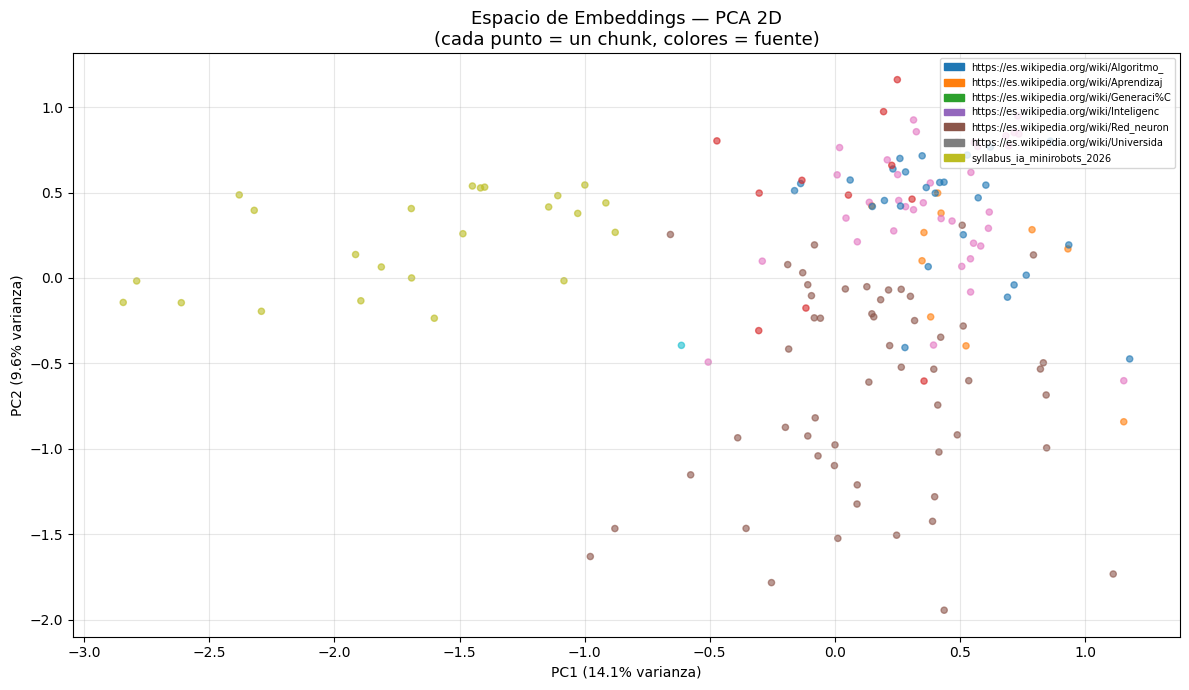

✓ Visualización guardada: embedding_space.png


In [12]:
from sklearn.decomposition import PCA
from sklearn.preprocessing import LabelEncoder

# Re-encodear los textos directamente (más robusto que extraer desde FAISS)
print(f'Generando embeddings para visualización ({len(rag.store)} chunks)...')
texts_viz = [c.text for c in rag.store.chunks]
all_embs = rag.embedder.encode(texts_viz, show_progress=True)

# Necesitamos al menos 2 muestras para PCA
n = len(all_embs)
assert n >= 2, f'Se necesitan al menos 2 chunks para PCA, hay {n}'
n_components = min(2, n)

# PCA a 2D
pca = PCA(n_components=n_components, random_state=42)
coords = pca.fit_transform(all_embs)
if n_components == 1:  # fallback si solo hay 1 chunk
    coords = np.hstack([coords, np.zeros((n, 1))])

# Colorear por fuente
sources = [c.source for c in rag.store.chunks]
le = LabelEncoder()
labels = le.fit_transform(sources)
unique_sources = le.classes_

fig, ax = plt.subplots(figsize=(12, 7))
scatter = ax.scatter(coords[:, 0], coords[:, 1], c=labels,
                     cmap='tab10', alpha=0.6, s=20)
patches = [mpatches.Patch(color=plt.cm.tab10(i / len(unique_sources)),
                           label=s[:40]) for i, s in enumerate(unique_sources)]
ax.legend(handles=patches, loc='upper right', fontsize=7, framealpha=0.8)
ax.set_title('Espacio de Embeddings — PCA 2D\n(cada punto = un chunk, colores = fuente)',
             fontsize=13)
ax.set_xlabel(f'PC1 ({pca.explained_variance_ratio_[0]*100:.1f}% varianza)')
ax.set_ylabel(f'PC2 ({pca.explained_variance_ratio_[1]*100:.1f}% varianza)')
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('embedding_space.png', dpi=150, bbox_inches='tight')
plt.show()
print('✓ Visualización guardada: embedding_space.png')

## Celda 12 — Evaluación del sistema: métricas de recuperación

Se evalúa la calidad del retrieval usando un conjunto de preguntas con respuestas esperadas
(ground truth). Se calculan **Precision@K**, **Recall@K** y **MRR** (Mean Reciprocal Rank).

In [13]:
# ── Ground truth para evaluación ─────────────────────────────────
EVAL_SET = [
    {
        'question': '¿Cuántos créditos tiene el curso de IA y Minirobots?',
        'keywords': ['créditos', '3', 'código', '2023251']
    },
    {
        'question': '¿Qué temas cubre el módulo de redes neuronales?',
        'keywords': ['neurona', 'retro-propagación', 'feed-forward', 'activación']
    },
    {
        'question': '¿Cuál es la metodología del curso?',
        'keywords': ['magistrales', 'talleres', 'programación', '60%', '40%']
    },
    {
        'question': '¿Qué es un algoritmo genético?',
        'keywords': ['genético', 'aptitud', 'complejidad', 'operadores']
    },
    {
        'question': '¿Qué profesores dictan el curso?',
        'keywords': ['martínez', 'pérez', 'prieto', 'profesor']
    },
]

def hit_at_k(chunks: List[Chunk], keywords: List[str], k: int) -> bool:
    """Verifica si alguno de los top-k chunks contiene al menos una keyword."""
    for chunk in chunks[:k]:
        text_lower = chunk.text.lower()
        if any(kw.lower() in text_lower for kw in keywords):
            return True
    return False

def mrr(chunks: List[Chunk], keywords: List[str]) -> float:
    """Mean Reciprocal Rank: 1/posición del primer hit relevante."""
    for i, chunk in enumerate(chunks, 1):
        if any(kw.lower() in chunk.text.lower() for kw in keywords):
            return 1.0 / i
    return 0.0

results_eval = []
print('Evaluando sistema RAG...\n')
for item in EVAL_SET:
    q_emb = embedder.encode([item['question']], show_progress=False)[0]
    candidates = rag.store.search(q_emb, top_k=10)
    reranked    = reranker.rerank(item['question'], candidates, top_k=4)
    chunks_ret  = [c for c, _ in candidates]
    chunks_rer  = [c for c, _ in reranked]

    r = {
        'question'    : item['question'][:50],
        'hit@5_dense' : hit_at_k(chunks_ret, item['keywords'], 5),
        'hit@4_rerank': hit_at_k(chunks_rer, item['keywords'], 4),
        'mrr_dense'   : mrr(chunks_ret, item['keywords']),
        'mrr_rerank'  : mrr(chunks_rer, item['keywords']),
    }
    results_eval.append(r)
    print(f"  Q: {r['question']}")
    print(f"     Hit@5 dense={r['hit@5_dense']} | Hit@4 rerank={r['hit@4_rerank']} | MRR dense={r['mrr_dense']:.2f} | MRR rerank={r['mrr_rerank']:.2f}")

avg_mrr_dense  = np.mean([r['mrr_dense']  for r in results_eval])
avg_mrr_rerank = np.mean([r['mrr_rerank'] for r in results_eval])
hit5_dense     = np.mean([r['hit@5_dense']  for r in results_eval])
hit4_rerank    = np.mean([r['hit@4_rerank'] for r in results_eval])

print(f'\n── Resumen ──────────────────────────────────')
print(f'  Hit@5  (dense)  : {hit5_dense:.2%}')
print(f'  Hit@4  (rerank) : {hit4_rerank:.2%}')
print(f'  MRR    (dense)  : {avg_mrr_dense:.3f}')
print(f'  MRR    (rerank) : {avg_mrr_rerank:.3f}')

Evaluando sistema RAG...

  Q: ¿Cuántos créditos tiene el curso de IA y Minirobot
     Hit@5 dense=True | Hit@4 rerank=True | MRR dense=1.00 | MRR rerank=1.00
  Q: ¿Qué temas cubre el módulo de redes neuronales?
     Hit@5 dense=True | Hit@4 rerank=True | MRR dense=1.00 | MRR rerank=1.00
  Q: ¿Cuál es la metodología del curso?
     Hit@5 dense=False | Hit@4 rerank=True | MRR dense=0.11 | MRR rerank=1.00
  Q: ¿Qué es un algoritmo genético?
     Hit@5 dense=True | Hit@4 rerank=True | MRR dense=1.00 | MRR rerank=1.00
  Q: ¿Qué profesores dictan el curso?
     Hit@5 dense=True | Hit@4 rerank=True | MRR dense=0.33 | MRR rerank=1.00

── Resumen ──────────────────────────────────
  Hit@5  (dense)  : 80.00%
  Hit@4  (rerank) : 100.00%
  MRR    (dense)  : 0.689
  MRR    (rerank) : 1.000


## Celda 13 — Visualización de métricas de evaluación

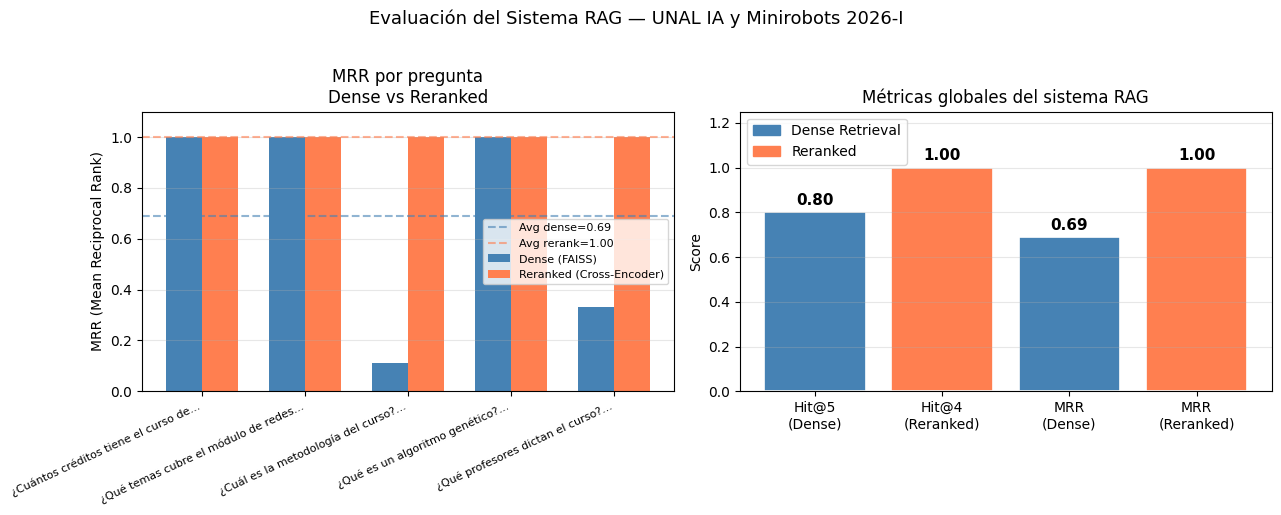

✓ Gráfica guardada: metricas_rag.png


In [14]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# ── Gráfica 1: MRR por pregunta ───────────────────────────────────
ax = axes[0]
qs = [r['question'][:35] + '...' for r in results_eval]
x  = np.arange(len(qs))
w  = 0.35
ax.bar(x - w/2, [r['mrr_dense']  for r in results_eval], w, label='Dense (FAISS)', color='steelblue')
ax.bar(x + w/2, [r['mrr_rerank'] for r in results_eval], w, label='Reranked (Cross-Encoder)', color='coral')
ax.axhline(avg_mrr_dense,  color='steelblue', linestyle='--', alpha=0.6, label=f'Avg dense={avg_mrr_dense:.2f}')
ax.axhline(avg_mrr_rerank, color='coral',     linestyle='--', alpha=0.6, label=f'Avg rerank={avg_mrr_rerank:.2f}')
ax.set_xticks(x)
ax.set_xticklabels(qs, rotation=25, ha='right', fontsize=8)
ax.set_ylabel('MRR (Mean Reciprocal Rank)')
ax.set_title('MRR por pregunta\nDense vs Reranked')
ax.legend(fontsize=8)
ax.set_ylim(0, 1.1)
ax.grid(axis='y', alpha=0.3)

# ── Gráfica 2: Comparación global ────────────────────────────────
ax2 = axes[1]
metrics = ['Hit@5\n(Dense)', 'Hit@4\n(Reranked)', 'MRR\n(Dense)', 'MRR\n(Reranked)']
values  = [hit5_dense, hit4_rerank, avg_mrr_dense, avg_mrr_rerank]
colors  = ['steelblue', 'coral', 'steelblue', 'coral']
bars = ax2.bar(metrics, values, color=colors, edgecolor='white', linewidth=1.2)
for bar, val in zip(bars, values):
    ax2.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.02,
             f'{val:.2f}', ha='center', va='bottom', fontsize=11, fontweight='bold')
ax2.set_ylim(0, 1.25)
ax2.set_title('Métricas globales del sistema RAG')
ax2.set_ylabel('Score')
ax2.grid(axis='y', alpha=0.3)
blue_patch  = mpatches.Patch(color='steelblue', label='Dense Retrieval')
coral_patch = mpatches.Patch(color='coral',     label='Reranked')
ax2.legend(handles=[blue_patch, coral_patch])

plt.suptitle('Evaluación del Sistema RAG — UNAL IA y Minirobots 2026-I', fontsize=13, y=1.02)
plt.tight_layout()
plt.savefig('metricas_rag.png', dpi=150, bbox_inches='tight')
plt.show()
print('✓ Gráfica guardada: metricas_rag.png')

## Celda 14 — Chat interactivo con el sistema RAG

Aquí puedes hacer preguntas en lenguaje natural sobre la UNAL y el curso.

In [15]:
# ── Preguntas de demostración ─────────────────────────────────────
demo_questions = [
    '¿Cuántos créditos tiene el curso de IA y Minirobots y cuál es su código?',
    '¿Qué temas se ven en el módulo de algoritmos genéticos?',
    '¿Cómo se evalúa el curso y qué porcentaje corresponde a los talleres?',
    '¿Qué es la programación genética y para qué se usa?',
]

for q in demo_questions:
    result = rag.query(q, verbose=True)
    print()


Pregunta: ¿Cuántos créditos tiene el curso de IA y Minirobots y cuál es su código?

Respuesta:
Según el syllabus del curso de IA y Minirobots, el curso tiene 3 créditos y su código es el 2023251.

Fuentes utilizadas:
  [1] Syllabus IA y Minirobots 2026-I (score=2.5913) — syllabus_ia_minirobots_2026
  [2] Inteligencia artificial - Wikipedia, la enciclopedia libre (score=-4.5235) — https://es.wikipedia.org/wiki/Inteligencia_artificial
  [3] Inteligencia artificial - Wikipedia, la enciclopedia libre (score=-4.8079) — https://es.wikipedia.org/wiki/Inteligencia_artificial
  [4] Inteligencia artificial - Wikipedia, la enciclopedia libre (score=-5.3757) — https://es.wikipedia.org/wiki/Inteligencia_artificial

Tiempo total: 75.10s



KeyboardInterrupt: 

## Celda 15 — Chat libre (ejecutar repetidamente)

In [17]:
# Cambia la pregunta y re-ejecuta esta celda para chatear
mi_pregunta = '¿Qué diferencia hay entre aprendizaje supervisado y no supervisado?'

_ = rag.chat(mi_pregunta)


Pregunta: ¿Qué diferencia hay entre aprendizaje supervisado y no supervisado?

Respuesta:
El aprendizaje supervisado se refiere a un tipo de aprendizaje automático donde la máquina es entrenada con datos etiquetados, lo que significa que ya se conoce la respuesta correcta para cada ejemplo. El objetivo del modelo es aprender a predecir o clasificar los datos en función de las etiquetas proporcionadas.

Por otro lado, el aprendizaje no supervisado (también conocido como aprendizaje semisupervisado) se refiere a un tipo de aprendizaje automático donde la máquina es entrenada con datos sin etiquetas. En este caso, el modelo debe aprender a identificar patrones o características en los datos a través del proceso de aprendizaje y encontrar formas de asignar etiquetas auto-organizadas.

En este contexto, el aprendizaje supervisado está estrechamente relacionado con la hipótesis de aprendizaje de Hebb, que propone que las conexiones entre neuronas se fortalecen cuando dos neuronas transmiten

## Celda 16 — Historial de conversación

In [18]:
print(f'Total de consultas realizadas: {len(rag.history)}\n')
for i, h in enumerate(rag.history, 1):
    print(f'[{i}] Q: {h["question"]}')
    print(f'    Tiempo: {h["elapsed_s"]}s | Chunks recuperados: {h["n_retrieved"]}')
    print(f'    Fuentes: {[s["title"] for s in h["sources"]]}')
    print()

Total de consultas realizadas: 3

[1] Q: ¿Cuántos créditos tiene el curso de IA y Minirobots y cuál es su código?
    Tiempo: 75.1s | Chunks recuperados: 10
    Fuentes: ['Syllabus IA y Minirobots 2026-I', 'Inteligencia artificial - Wikipedia, la enciclopedia libre', 'Inteligencia artificial - Wikipedia, la enciclopedia libre', 'Inteligencia artificial - Wikipedia, la enciclopedia libre']

[2] Q: ¿Qué diferencia hay entre aprendizaje supervisado y no supervisado?
    Tiempo: 109.32s | Chunks recuperados: 10
    Fuentes: ['Red neuronal artificial - Wikipedia, la enciclopedia libre', 'Inteligencia artificial - Wikipedia, la enciclopedia libre', 'Red neuronal artificial - Wikipedia, la enciclopedia libre', 'Aprendizaje automático - Wikipedia, la enciclopedia libre']

[3] Q: ¿Qué diferencia hay entre aprendizaje supervisado y no supervisado?
    Tiempo: 54.67s | Chunks recuperados: 10
    Fuentes: ['Red neuronal artificial - Wikipedia, la enciclopedia libre', 'Inteligencia artificial - Wik

## Celda 17 — Análisis de latencia del pipeline

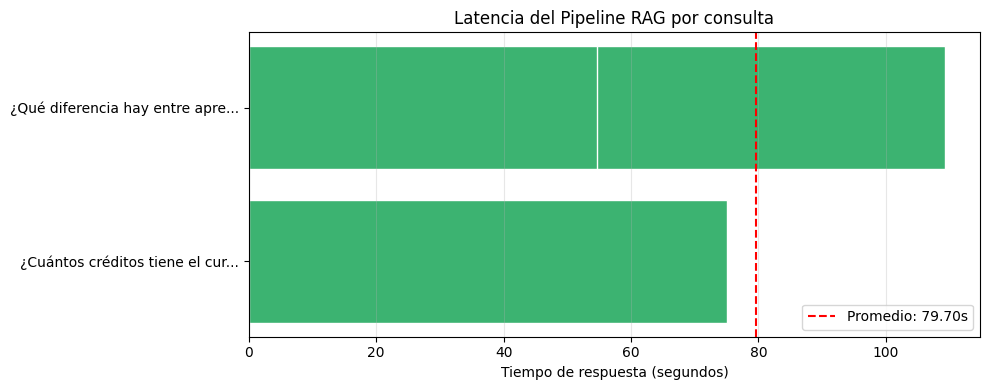

Latencia promedio: 79.70s | Máx: 109.32s | Mín: 54.67s


In [19]:
if rag.history:
    tiempos = [h['elapsed_s'] for h in rag.history]
    preguntas = [h['question'][:30] + '...' for h in rag.history]

    fig, ax = plt.subplots(figsize=(10, 4))
    ax.barh(preguntas, tiempos, color='mediumseagreen', edgecolor='white')
    ax.axvline(np.mean(tiempos), color='red', linestyle='--',
               label=f'Promedio: {np.mean(tiempos):.2f}s')
    ax.set_xlabel('Tiempo de respuesta (segundos)')
    ax.set_title('Latencia del Pipeline RAG por consulta')
    ax.legend()
    ax.grid(axis='x', alpha=0.3)
    plt.tight_layout()
    plt.savefig('latencia_rag.png', dpi=150, bbox_inches='tight')
    plt.show()
    print(f'Latencia promedio: {np.mean(tiempos):.2f}s | Máx: {max(tiempos):.2f}s | Mín: {min(tiempos):.2f}s')

## Celda 18 — Agregar nuevas fuentes al índice existente

In [ ]:
def add_url_to_index(url: str):
    """Agrega una nueva URL al índice RAG sin reconstruirlo desde cero."""
    doc = WebLoader.load(url)
    if not doc:
        print(f'No se pudo cargar: {url}')
        return
    chunks = chunker.chunk(doc)
    texts  = [c.text for c in chunks]
    embs   = embedder.encode(texts, show_progress=False)
    rag.store.add(chunks, embs)
    rag.save_index()
    print(f'✓ Agregado: {doc.title} ({len(chunks)} chunks) — Total: {len(rag.store)}')


def add_pdf_to_index(path: str):
    """Agrega un PDF local al índice RAG."""
    doc    = PDFLoader.load(path)
    chunks = chunker.chunk(doc)
    texts  = [c.text for c in chunks]
    embs   = embedder.encode(texts, show_progress=False)
    rag.store.add(chunks, embs)
    rag.save_index()
    print(f'✓ PDF agregado: {doc.title} ({len(chunks)} chunks) — Total: {len(rag.store)}')


# Ejemplo de uso:
# add_url_to_index('https://unal.edu.co/noticias/detalle/nueva-noticia.html')
# add_pdf_to_index('mi_documento.pdf')
print('✓ Funciones de actualización incremental listas')

## Celda 19 — Conclusiones y análisis académico

### ¿Qué es RAG?

**Retrieval-Augmented Generation (RAG)** combina dos paradigmas:
- **Recuperación de información** (IR): busca fragmentos relevantes en una base de conocimiento
- **Generación de lenguaje** (LLM): produce respuestas coherentes condicionadas al contexto recuperado

Esto resuelve las limitaciones principales de los LLMs puros:
| Problema LLM puro | Solución RAG |
|---|---|
| Conocimiento desactualizado | Fuentes actualizables en tiempo real |
| Alucinaciones | Respuestas ancladas en documentos reales |
| Sin trazabilidad | Citas explícitas de fuentes |
| Contexto limitado | Recuperación selectiva de información relevante |

### Arquitectura implementada

```
Bi-encoder (SBERT)  →  FAISS (ANN)  →  Cross-encoder (reranking)  →  LLM
     ↑                                          ↑
  Velocidad                                  Precisión
```

El pipeline de dos etapas (retrieve → rerank) balancea eficiencia y calidad:
- El **bi-encoder** es rápido pero menos preciso (O(1) con FAISS)
- El **cross-encoder** es preciso pero lento (solo se aplica a top-K candidatos)

### Extensiones posibles
- **HyDE** (Hypothetical Document Embeddings): generar un documento hipotético antes de buscar
- **Multi-query retrieval**: expandir la consulta con paráfrasis automáticas
- **Contextual compression**: comprimir chunks antes de enviarlos al LLM
- **Graph RAG**: usar grafos de conocimiento para relaciones entre entidades
- **Agentic RAG**: el LLM decide cuándo y qué recuperar (tool use)

In [20]:
# ── Resumen final del sistema ─────────────────────────────────────
print('=' * 60)
print('RESUMEN DEL SISTEMA RAG')
print('=' * 60)
print(f'  Documentos ingestados : {len(documents)}')
print(f'  Chunks indexados      : {len(rag.store)}')
print(f'  Dimensión embedding   : {embedder.dim}')
print(f'  Modelo embedding      : {CFG["embed_model"]}')
print(f'  Modelo reranking      : {CFG["rerank_model"]}')
print(f'  LLM provider          : {CFG["llm_provider"]} / {CFG["llm_model"]}')
print(f'  Top-K retrieve        : {CFG["top_k_retrieve"]}')
print(f'  Top-K rerank          : {CFG["top_k_rerank"]}')
print(f'  Consultas realizadas  : {len(rag.history)}')
if rag.history:
    avg_t = np.mean([h["elapsed_s"] for h in rag.history])
    print(f'  Latencia promedio     : {avg_t:.2f}s')
print('=' * 60)

RESUMEN DEL SISTEMA RAG
  Documentos ingestados : 7
  Chunks indexados      : 163
  Dimensión embedding   : 384
  Modelo embedding      : paraphrase-multilingual-MiniLM-L12-v2
  Modelo reranking      : cross-encoder/ms-marco-MiniLM-L-6-v2
  LLM provider          : ollama / gpt-4o-mini
  Top-K retrieve        : 10
  Top-K rerank          : 4
  Consultas realizadas  : 3
  Latencia promedio     : 79.70s
